Install the required Libraries

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [2]:
# import the dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [3]:
#load the dataset
titanic = pd.read_csv("data/titanic.csv")

In [4]:
# Basic information 
print("Shape: ", titanic.shape)
print("-"*50)
print("Info: ", titanic.info())
print("-"*50)
print("Describe: ", titanic.describe())

Shape:  (891, 12)
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
Info:  None
--------------------------------------------------
Describe:         PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  71

In [5]:
titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [6]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
titanic.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [8]:
# Handling missing values
print(titanic.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
titanic["Embarked"].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [10]:
titanic.Cabin.isnull()

0       True
1      False
2       True
3      False
4       True
       ...  
886     True
887    False
888     True
889    False
890     True
Name: Cabin, Length: 891, dtype: bool

In [11]:
titanic.drop("Cabin", axis=1, inplace=True)

In [13]:
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [14]:
titanic["Age"] = titanic["Age"].fillna(titanic["Age"].mean())

In [15]:
titanic["Embarked"] = titanic["Embarked"].fillna(titanic["Embarked"].mode()[0])

In [16]:
print(titanic.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [17]:
# Survived vs Not Survived in the ship
print(titanic["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


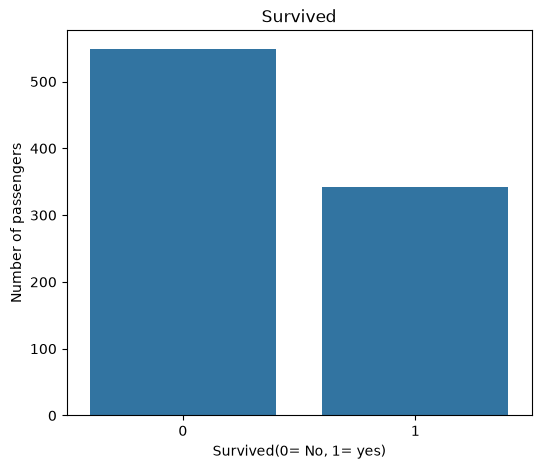

In [18]:
# Visualization
plt.figure(figsize=(6,5))
sns.countplot(x="Survived", data=titanic)

plt.title("Survived")
plt.xlabel("Survived(0= No, 1= yes)")
plt.ylabel("Number of passengers")
plt.show()

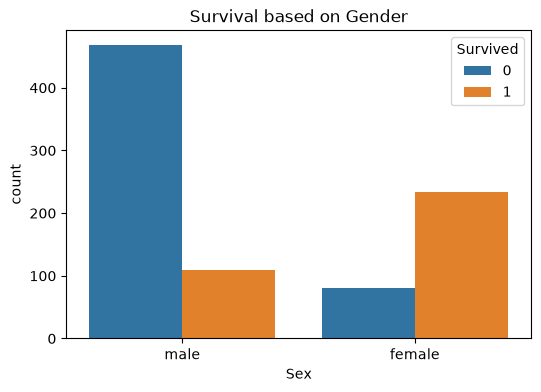

In [19]:
# Survival based on Gender
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=titanic)
plt.title("Survival based on Gender")
plt.show()

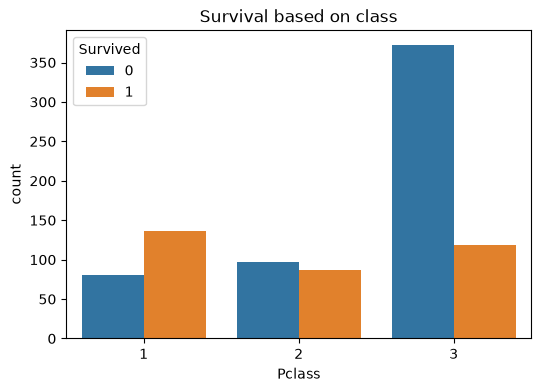

In [20]:
#Survival based on passenger class
plt.figure(figsize=(6,4))
sns.countplot(x= "Pclass", hue="Survived", data=titanic)
plt.title("Survival based on class")
plt.show()

In [21]:
# Average Age and Average fare
average_age = titanic["Age"].mean()
print("Average Age: ", average_age)

average_fare = titanic["Fare"].mean()
print("Average Fare: ", average_fare)


Average Age:  29.69911764705882
Average Fare:  32.204207968574636


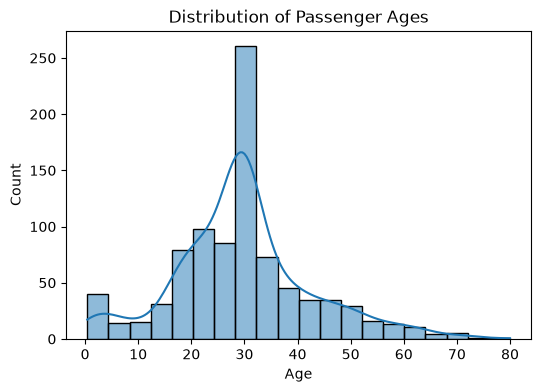

In [ ]:
#Visualization
plt.figure(figsize=(6,4))
sns.histplot(titanic["Age"], bins=20, kde=True)
plt.title("Distribution of Passenger Fares")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()


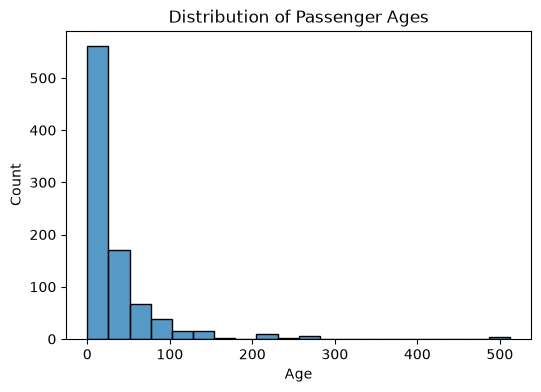

In [23]:
#Visualization by fare
plt.figure(figsize=(6,4))
sns.histplot(titanic["Fare"], bins=20)
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [24]:
# Compare survival across ages
titanic["AgeGroup"] = pd.cut(
    titanic["Age"],
    bins=[0,12,18,35,60,100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

In [25]:
print(titanic.groupby("AgeGroup")["Survived"].mean())

AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


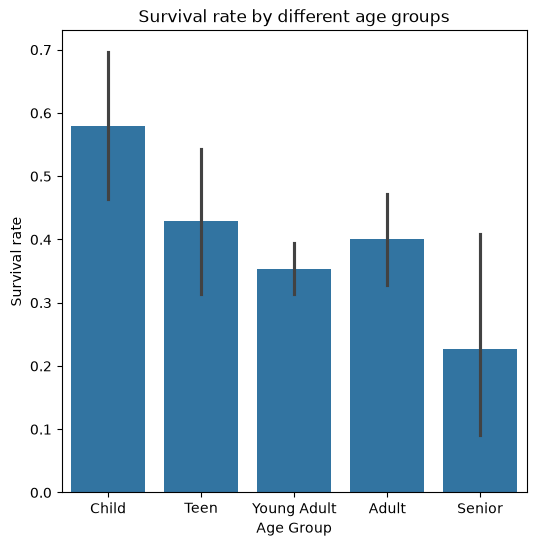

In [26]:
# Visualize 
plt.figure(figsize=(6,6))
sns.barplot(x="AgeGroup", y="Survived", data=titanic)
plt.title("Survival rate by different age groups")
plt.xlabel("Age Group")
plt.ylabel("Survival rate")
plt.show()

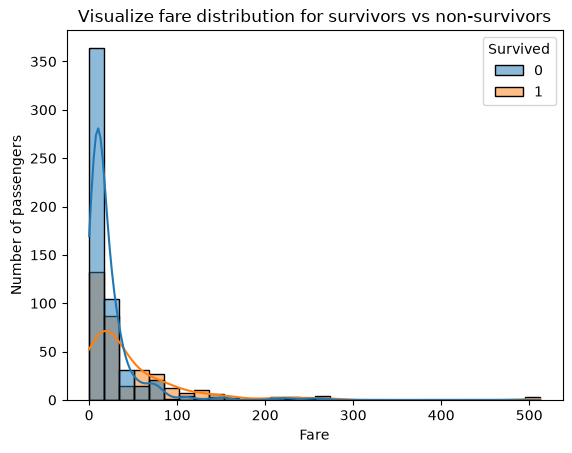

In [27]:
# Visualize fare distribution for survivors vs non-survivors

sns.histplot(
    data= titanic,
    x="Fare",
    hue="Survived",
    bins=30,
    kde=True
)
plt.title("Visualize fare distribution for survivors vs non-survivors")
plt.xlabel("Fare")
plt.ylabel("Number of passengers")
plt.show()